# Часть 1 Бустинг (5 баллов)

В этой части будем предсказывать зарплату data scientist-ов в зависимости  от ряда факторов с помощью градиентного бустинга.

В датасете есть следующие признаки:



* work_year: The number of years of work experience in the field of data science.

* experience_level: The level of experience, such as Junior, Senior, or Lead.

* employment_type: The type of employment, such as Full-time or Contract.

* job_title: The specific job title or role, such as Data Analyst or Data Scientist.

* salary: The salary amount for the given job.

* salary_currency: The currency in which the salary is denoted.

* salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

* employee_residence: The country or region where the employee resides.

* remote_ratio: The percentage of remote work offered in the job.

* company_location: The location of the company or organization.

* company_size: The company's size is categorized as Small, Medium, or Large.

In [1]:
import pandas as pd

df = pd.read_csv("ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Задание 1 (0.5 балла) Подготовка



*   Разделите выборку на train, val, test (80%, 10%, 10%)
*   Выдерите salary_in_usd в качестве таргета
*   Найдите и удалите признак, из-за которого возможен лик в данных


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['salary', 'salary_in_usd'], axis=1)
y = df['salary_in_usd']

X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, train_size=0.8, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, train_size=0.5, random_state=42)

## Задание 2 (0.5 балла) Линейная модель


*   Закодируйте категориальные  признаки с помощью OneHotEncoder
*   Обучите модель линейной регрессии
*   Оцените  качество через MAPE и RMSE


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder

# * work_year: The number of years of work experience in the field of data science.
# * experience_level: The level of experience, such as Junior, Senior, or Lead.
# * employment_type: The type of employment, such as Full-time or Contract.
# * job_title: The specific job title or role, such as Data Analyst or Data Scientist.
# * salary: The salary amount for the given job.
# * salary_currency: The currency in which the salary is denoted.
# * salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.
# * employee_residence: The country or region where the employee resides.
# * remote_ratio: The percentage of remote work offered in the job.
# * company_location: The location of the company or organization.
# * company_size: The company's size is categorized as Small, Medium, or Large.

encoder = OneHotEncoder(sparse_output=False)
categorical_features = encoder.fit_transform(X[['work_year', 'experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']])

X_train, X_val_test, y_train, y_val_test = train_test_split(categorical_features, y, train_size=0.8, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, train_size=0.5, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('MAPE: ', mean_absolute_percentage_error(y_test, y_pred))
print('RMSE: ', root_mean_squared_error(y_test, y_pred))


MAPE:  0.3776320860493682
RMSE:  51735.879292812715


## Задание 3 (0.5 балла) XGboost

Начнем с библиотеки xgboost.

Обучите модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [39]:
from xgboost.sklearn import XGBRegressor
from sklearn.model_selection import GridSearchCV

params = {
    "max_depth": [3, 7, 15],
    "learning_rate": [i / 1000.0 for i in range(1, 301, 100)],
    "n_estimators": [i for i in range(50, 551, 100)],
    "gamma": [0, 1, 5],
}

model = XGBRegressor()

grid_search = GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    error_score="raise",
)

grid_search.fit(X_train, y_train)
y_pred_val = grid_search.predict(X_val)

print("MAPE: ", mean_absolute_percentage_error(y_val, y_pred_val))
print("RMSE: ", root_mean_squared_error(y_val, y_pred_val))
print("Best params: ", grid_search.best_params_)

# Норм, моделька чуть хуже в MAPE, но больших отклонений у нее явно меньше, судя по MSE

MAPE:  0.38778549432754517
RMSE:  44974.6328125
Best params:  {'gamma': 0, 'learning_rate': 0.101, 'max_depth': 3, 'n_estimators': 250}


## Задание 4 (1 балл) CatBoost

Теперь библиотека CatBoost.

Обучите модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [40]:
from catboost import CatBoostRegressor

params = {
    "depth": [3, 7, 10],
    "learning_rate": [i / 1000.0 for i in range(100, 301, 100)],
    "n_estimators": [50, 100, 150],
}


model = CatBoostRegressor()

grid_search = GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    error_score="raise",
)

grid_search.fit(X_train, y_train)
y_pred_val = grid_search.predict(X_val)

print("MAPE: ", mean_absolute_percentage_error(y_val, y_pred_val))
print("RMSE: ", root_mean_squared_error(y_val, y_pred_val))
print("Best params: ", grid_search.best_params_)

# Да вроде быстро, MAPE опыть же вырос, RMSE опять упал


0:	learn: 61012.6469872	total: 56ms	remaining: 2.75s
1:	learn: 59497.4446903	total: 56.4ms	remaining: 1.35s
2:	learn: 58166.6064264	total: 56.6ms	remaining: 886ms
0:	learn: 61570.8350552	total: 58.2ms	remaining: 2.85s
3:	learn: 57193.2063832	total: 56.8ms	remaining: 654ms
1:	learn: 60023.2439643	total: 58.4ms	remaining: 1.4s
4:	learn: 56103.6693967	total: 57.1ms	remaining: 514ms
2:	learn: 58516.1913389	total: 58.7ms	remaining: 919ms
5:	learn: 55344.3246838	total: 57.3ms	remaining: 421ms
3:	learn: 57197.4860821	total: 58.9ms	remaining: 677ms
6:	learn: 54765.2632435	total: 57.5ms	remaining: 354ms
4:	learn: 56191.7078880	total: 59.1ms	remaining: 532ms
7:	learn: 54074.7908180	total: 57.8ms	remaining: 303ms
5:	learn: 55215.4380332	total: 59.4ms	remaining: 435ms
8:	learn: 53575.3168024	total: 58ms	remaining: 264ms
6:	learn: 54471.7905101	total: 59.6ms	remaining: 366ms
9:	learn: 53050.6748732	total: 58.2ms	remaining: 233ms
7:	learn: 53857.9568384	total: 59.8ms	remaining: 314ms
10:	learn: 5266

Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?

In [45]:
from catboost import Pool

# * work_year: The number of years of work experience in the field of data science.
# * experience_level: The level of experience, such as Junior, Senior, or Lead.
# * employment_type: The type of employment, such as Full-time or Contract.
# * job_title: The specific job title or role, such as Data Analyst or Data Scientist.
# * salary: The salary amount for the given job.
# * salary_currency: The currency in which the salary is denoted.
# * salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.
# * employee_residence: The country or region where the employee resides.
# * remote_ratio: The percentage of remote work offered in the job.
# * company_location: The location of the company or organization.
# * company_size: The company's size is categorized as Small, Medium, or Large.

ct = [
    "work_year",
    "experience_level",
    "employment_type",
    "job_title",
    "salary_currency",
    "employee_residence",
    "remote_ratio",
    "company_location",
    "company_size",
]

X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, train_size=0.8, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, train_size=0.5, random_state=42)

train_pool = Pool(
    X_train,
    y_train,
    cat_features=ct,
)
val_pool = Pool(
    X_val,
    y_val,
    cat_features=ct,
)
test_pool = Pool(
    X_test,
    y_test,
    cat_features=ct,
)

model = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6)
model.fit(train_pool, eval_set=val_pool)

y_pred = model.predict(test_pool)

print("MAPE: ", mean_absolute_percentage_error(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred))

# Стало как в линейной регрессии

0:	learn: 61297.5645016	test: 59754.8861122	best: 59754.8861122 (0)	total: 2.72ms	remaining: 270ms
1:	learn: 59711.8725950	test: 57939.1596874	best: 57939.1596874 (1)	total: 5.22ms	remaining: 256ms
2:	learn: 58515.7536478	test: 56627.8537887	best: 56627.8537887 (2)	total: 6.53ms	remaining: 211ms
3:	learn: 57375.8582565	test: 55387.9001873	best: 55387.9001873 (3)	total: 7.75ms	remaining: 186ms
4:	learn: 56438.0600576	test: 54360.8350825	best: 54360.8350825 (4)	total: 8.64ms	remaining: 164ms
5:	learn: 55659.4863420	test: 53510.1759438	best: 53510.1759438 (5)	total: 9.48ms	remaining: 148ms
6:	learn: 54992.0848924	test: 52779.2442946	best: 52779.2442946 (6)	total: 10.4ms	remaining: 138ms
7:	learn: 54384.0301228	test: 52112.2635927	best: 52112.2635927 (7)	total: 11.3ms	remaining: 130ms
8:	learn: 53885.8848927	test: 51557.5117441	best: 51557.5117441 (8)	total: 12.2ms	remaining: 123ms
9:	learn: 53343.3447841	test: 50963.9574308	best: 50963.9574308 (9)	total: 13ms	remaining: 117ms
10:	learn: 5

**Ответ:** # -- YOUR ANSWER HERE --

## Задание 5 (0.5 балла) LightGBM

И наконец библиотека LightGBM - используйте `LGBMRegressor`, снова подберите гиперпараметры, оцените качество и скорость.


In [42]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error

encoder = OneHotEncoder(sparse_output=False)
categorical_features = encoder.fit_transform(X[['work_year', 'experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']])

X_train, X_val_test, y_train, y_val_test = train_test_split(categorical_features, y, train_size=0.8, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, train_size=0.5, random_state=42)

params = {
    "max_depth": [3, 7, 10],
    "learning_rate": [i / 1000.0 for i in range(100, 301, 100)],
    "n_estimators": [50, 100, 150],
    "num_leaves": [31, 50, 70],
}

model = LGBMRegressor()

grid_search = GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    error_score="raise",
)

grid_search.fit(X_train, y_train)

y_pred_val = grid_search.predict(X_val)

print("MAPE: ", mean_absolute_percentage_error(y_val, y_pred_val))
print("RMSE: ", root_mean_squared_error(y_val, y_pred_val))
print("Best params: ", grid_search.best_params_)



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009438 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 82
[LightGBM] [Info] Number of data points in the train set: 2403, number of used features: 41
[LightGBM] [Info] Start training from score 137876.872659
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 82
[LightGBM] [Info] Number of data points in the train set: 2403, number of used features: 41
[LightGBM] [Info] Start training from score 137935.096130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012037 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Tota

/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserW

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserW

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000852 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 86
[LightGBM] [Info] Number of data points in the train set: 3004, number of used features: 43
[LightGBM] [Info] Start training from score 138055.989348
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

/Users/developer/hse/iad/iad-intro-ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Задание 6 (2 балла) Сравнение и выводы

Сравните модели бустинга и сделайте про них выводы, какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?

**Ответ:** Нельзя выделить какого-то лидера. Все модели отклоняются по MAS в верхнюю сторону и MSE в нижнюю. На одинаковой сетке гиперпараметров требуют одинковое время для обучения (50 секунд).

Гиперпараметры тоже получились одинаковые по глубине, learning_rate и n_estimators. Тяжело... Тяжело...

# Часть 2 Кластеризация (5 баллов)

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [1]:
import pandas as pd
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.

## Задание 1 (0.5 балла) Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [2]:
ratings = ratings.T

Выкиньте строку под названием `user`.

In [10]:
ratings = ratings.drop('user')
ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modest mouse,NaN,NaN,NaN,NaN,0.015935,NaN,NaN,NaN,NaN,0.030437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [11]:
# -- YOUR CODE HERE --
ratings = ratings.fillna(0)
ratings.sample()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the rolling stones,0.0,0.0,0.024559,0.0,0.0,0.0,0.0,0.0,0.0,0.023829,...,0.0,0.0,0.0,0.0,0.005774,0.0,0.0,0.0,0.0,0.0


## Задание 2 (0.5 балла) Первая кластеризация

Примените KMeans с 5ю кластерами, сохраните полученные лейблы

In [29]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=5)

model.fit(ratings)

labels = model.labels_

Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [30]:
cnt = pd.Series(labels).value_counts().sort_index()
cnt
# да мало кластеров просто что сказать

0      1
1    996
2      1
3      1
4      1
Name: count, dtype: int64

**Ответ:** # -- YOUR ANSWER HERE --

## Задание 3 (0.5 балла) Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [31]:
cnt = pd.Series(labels).value_counts()
single_labels = set(cnt[cnt == 1].index)
rl = pd.DataFrame({
    'artist': ratings.index,
    'cluster': labels
})
singletons = rl[rl['cluster'].isin(single_labels)]
singletons

,artist,cluster
0,the beatles,4
38,animal collective,3
125,brritney spears,2
448,fatboy slim,0


Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.

In [41]:

n_users = (ratings > 0).sum(axis=1)
mean_among_listeners = ratings.copy()
mean_among_listeners[mean_among_listeners == 0] = pd.NA
mean_among_listeners = mean_among_listeners.mean(axis=1, skipna=True)
mean_all_users = ratings.mean(axis=1)
metrics = pd.DataFrame({
    'n_users': n_users,
    'mean_among_listeners': mean_among_listeners,
    'mean_all_users': mean_all_users
})
print(metrics)

                    n_users  mean_among_listeners  mean_all_users
the beatles            1671              0.054964        0.018369
radiohead              1389              0.042661        0.011851
deathcab for cutie      931              0.035141        0.006543
coldplay                841              0.035852        0.006030
modest mouse            814              0.036095        0.005876
...                     ...                   ...             ...
michal w. smith          47              0.095254        0.000895
群星                       47              0.055201        0.000519
agalloch                 47              0.106110        0.000997
meshuggah                47              0.045846        0.000431
yellowcard               47              0.034031        0.000320

[1000 rows x 3 columns]


**Ответ:** больше всех их слушают, настолько, что они в отдельном кластере.

## Задание 4 (0.5 балла) Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.

In [53]:
from sklearn.preprocessing import normalize

normalized_ratings_matrix = pd.DataFrame(
    normalize(ratings, norm="l2", axis=1),
    index=ratings.index,
    columns=ratings.columns,
)
normalized_ratings_matrix.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,0.000000,0.000000,0.000000,0.0,0.012054,0.000000,0.0,0.0,0.025864,0.004880,...,0.000000,0.0,0.033554,0.010569,0.002199,0.004952,0.0,0.021302,0.0,0.000000
radiohead,0.009348,0.084688,0.000000,0.0,0.039505,0.002894,0.0,0.0,0.000000,0.008771,...,0.008120,0.0,0.000000,0.000000,0.005122,0.000000,0.0,0.000000,0.0,0.000000
deathcab for cutie,0.000000,0.017278,0.020144,0.0,0.024333,0.000000,0.0,0.0,0.000000,0.009391,...,0.085361,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.019622
coldplay,0.000000,0.000000,0.000000,0.0,0.011129,0.000000,0.0,0.0,0.000000,0.000000,...,0.144628,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
modest mouse,0.000000,0.000000,0.000000,0.0,0.010260,0.000000,0.0,0.0,0.000000,0.019597,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000


Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [ ]:
model = KMeans(n_clusters=5)

model.fit(ratings)

labels = model.labels_

cnt = pd.Series(labels).value_counts().sort_index()
cnt

0      8
1      7
2    983
3      1
4      1
Name: count, dtype: int64

**Ответ** стало получше, но не сильно. выросло 2 single класса. 

## Задание 5 (1 балл) Центроиды

Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

In [54]:
from scipy.spatial.distance import cosine

top_artists_per_cluster = {}

for cluster_id in range(5):
    centroid = model.cluster_centers_[cluster_id]
    cluster_mask = (labels == cluster_id)
    cluster_artists = normalized_ratings_matrix[cluster_mask]
    distances = cluster_artists.apply(lambda row: cosine(row, centroid), axis=1)
    top_10 = distances.nsmallest(10).index.tolist()
    top_artists_per_cluster[f"Класс тер {cluster_id}"] = top_10
    
top_artists_per_cluster

{'Класс тер 0': ['newsboys',
  'michal w. smith',
  'jars of clay',
  'chris tomlin',
  'david crowder*band',
  'switchfoot',
  'relient k',
  'skillet'],
 'Класс тер 1': ['the beatles',
  'radiohead',
  'deathcab for cutie',
  'sufjan stevens',
  'modest mouse',
  'elliotte smith',
  'boards of canada'],
 'Класс тер 2': ['coldplay',
  'the shins',
  'kanye west',
  'the arcade fire',
  'the killers',
  'the pixies',
  'red hot clili peppers',
  'white stripes',
  'dylan. bob',
  'beck'],
 'Класс тер 3': ['daft punk'],
 'Класс тер 4': ['elvish presley']}

**Ответ:** пришлось погуглить и понять, что в мире существует какая-то музыка помимо мэдкида
0) почти все - это христианский рок
1) попса для элитариев лучше бы бабана послушали
2) попса для детей - в принципе, самая популярная категория, что и не удивительно.
3, 4) - мозг фанатов червив, они слушают одного исполнителя видимо всю жизнь 

смысл тут про то что ну как бы эээ дает понимание о слушателях этой группы и вполне успешно как-то кластеризовало адекватно

## Задание 6 (1 балл) Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?

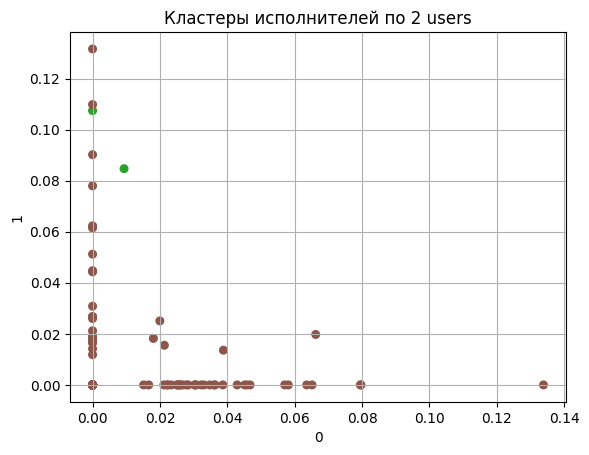

In [ ]:
import matplotlib.pyplot as plt

x_user = normalized_ratings_matrix.columns[0]
y_user = normalized_ratings_matrix.columns[1]

plt.scatter(
    normalized_ratings_matrix[x_user],
    normalized_ratings_matrix[y_user],
    c=labels,
    cmap='tab10',
    s=30
)
plt.xlabel(x_user)
plt.ylabel(y_user)
plt.title("Кластеры исполнителей по 2 users")
plt.grid(True)
plt.show()

**Ответ:** очень грубая проекция выходит - ничего не понятно.

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров

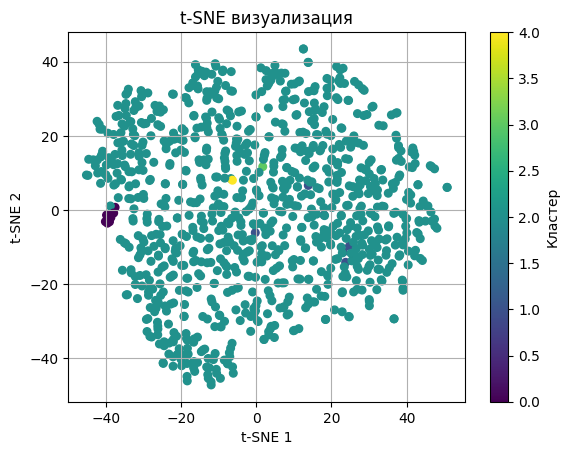

In [56]:
from sklearn.manifold import TSNE

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, metric='cosine', random_state=42)
embedding = tsne.fit_transform(normalized_ratings_matrix)
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='viridis', s=30)
plt.title("t-SNE визуализация")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label="Кластер")
plt.grid(True)
plt.show()

## Задание 7 (1 балл) Подбор гиперпараметров

Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []
k_range = range(2, 101)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(normalized_ratings_matrix)
    score = silhouette_score(normalized_ratings_matrix, labels)
    sil_scores.append(score)
        
best_k = k_range[sil_scores.index(max(sil_scores))]
print(best_k)

98


Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.

In [68]:
kmeans = KMeans(n_clusters=8, random_state=42, n_init='auto')

kmeans.fit(normalized_ratings_matrix)

labels = kmeans.labels_

top_artists_per_cluster = {}

for cluster_id in range(8):
    centroid = kmeans.cluster_centers_[cluster_id]
    cluster_mask = (labels == cluster_id)
    cluster_artists = normalized_ratings_matrix[cluster_mask]
    distances = cluster_artists.apply(lambda row: cosine(row, centroid), axis=1)
    top_10 = distances.nsmallest(3).index.tolist()
    top_artists_per_cluster[f"Класстер {cluster_id}"] = top_10
    
top_artists_per_cluster

{'Класстер 0': ['nas', 'jay-z', 'kanye west'],
 'Класстер 1': ['against me!', 'alkaline trio', 'descendents'],
 'Класстер 2': ['sufjan stevens', 'the arcade fire', 'broken social scene'],
 'Класстер 3': ['the beatles', 'led zeppelin.', 'the rolling stones'],
 'Класстер 4': ['dj shadow', 'portishead', 'rjd2'],
 'Класстер 5': ['janet jackson.', 'the pussycat dolls', 'rihanna & jay-z'],
 'Класстер 6': ['miles davis.', 'nina simone', 'Ｂille holiday'],
 'Класстер 7': ['fall out boy', 'paramore', 'the all-americian rejects']}

**Ответ:** Теперь более явное разделение на жанры 1) хип хоп 2) эмо панк 3) инди и тд...

Сделайте t-SNE визуализацию полученной кластеризации.

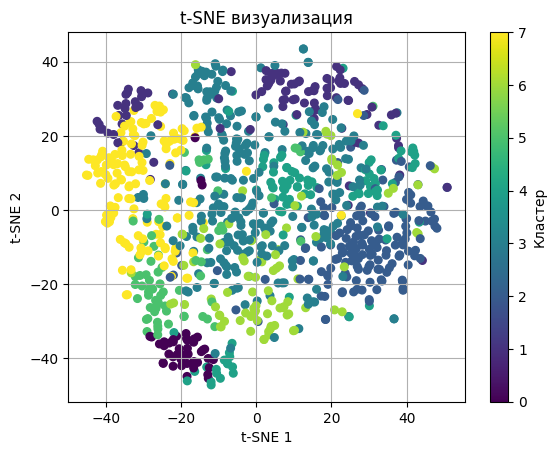

In [69]:
tsne = TSNE(n_components=2, perplexity=30, metric='cosine', random_state=42)
embedding = tsne.fit_transform(normalized_ratings_matrix)
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='viridis', s=30)
plt.title("t-SNE визуализация")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label="Кластер")
plt.grid(True)
plt.show()

Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?

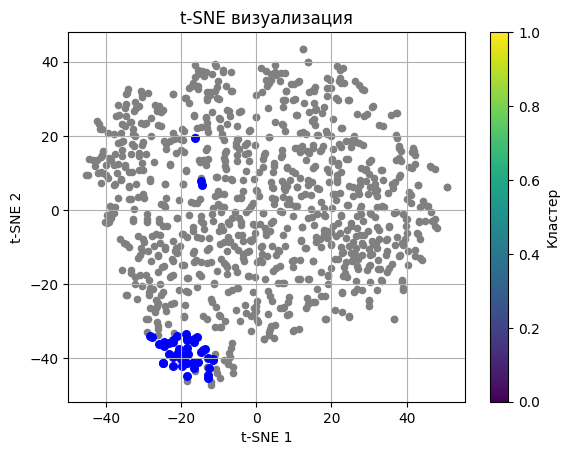

In [73]:
mask = (labels == 0) # rap
tsne = TSNE(n_components=2, perplexity=30, metric='cosine', random_state=42)
embedding = tsne.fit_transform(normalized_ratings_matrix)
scatter = plt.scatter(embedding[~mask, 0], embedding[~mask, 1], color='gray', s=20)
scatter = plt.scatter(embedding[mask, 0], embedding[mask, 1], color='blue', s=30)
plt.title("t-SNE визуализация")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label="Кластер")
plt.grid(True)
plt.show()

**Ответ:** нормально вот там где много синих точек - это короче кани вэст, там где мало - это солнце